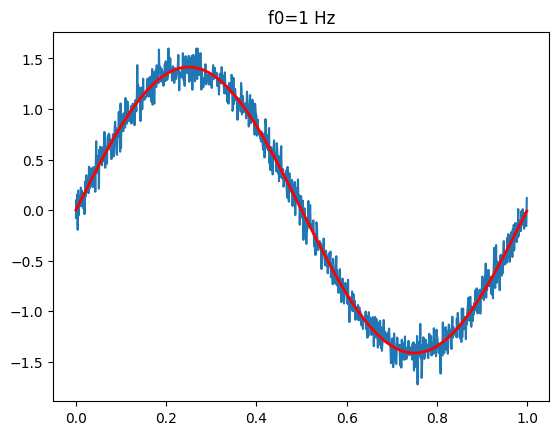

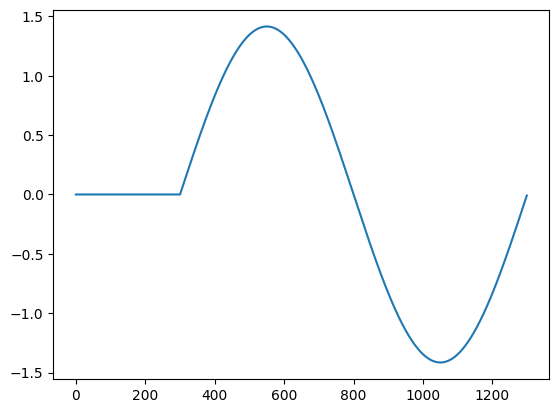

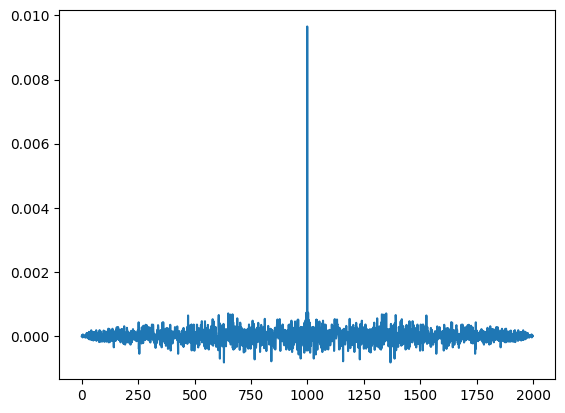

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Wed Mar 18 20:52:40 2026

@author: Geronimo Garcia
"""
import numpy as np

import matplotlib.pyplot as plt

#si toco ctrl + enter solo ejecuto la celda.
#%%
fs = 1000 #Hz, frecuencia de muestreo

f0 = 1 #Hz, frecuencia de la senoidal

n=1000 # muestras por ciclo

vmax=1 #volt

dc=0 #valor medio, volts

ts = 1 / fs

def mi_funcion_sen(vmax, dc, f0,n, fs, ph=0):
    tt=np.linspace(0, (n-1)*ts,n)
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt,xx=mi_funcion_sen(vmax, dc, f0,n, fs, ph=0)
#plt.subplot(2,1,1)
plt.plot(tt,xx)

#%%Señal con ruido
sigma=1
mu=0
U_n=np.random.normal(mu,sigma,n)
xxn=xx+U_n
#plt.subplot(2,1,2)
plt.plot(tt,xxn)

"""#%% f0=500 Hz
f0 = 500
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.title('f0 = 500 Hz')
plt.plot(tt, xx)

#%% f0=999 Hz
f0 = 999
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.title('f0 = 999 Hz')
plt.plot(tt, xx)

#%% f0=1001 Hz
f0 = 1001
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.title('f0 = 1001 Hz')
plt.plot(tt, xx)

#%% f0=2001 Hz
f0 = 2001
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.title('f0 = 2001 Hz')
plt.plot(tt, xx)

"""
#ph es fase
#niqwist
"""
#%%
"""#f0=35
#tt,xx=mi_funcion(vmax, dc, f0,n, fs, ph=np.pi/2)
#plt.plot(tt,xx)
#Potencia de la senoidal es A^2/2  #A es vmax
#Potencia del ruido es sigma^2
"""
"""
#%% Potencia de señal
#potencia es **
vmax=np.sqrt(2)
tt,xx=mi_funcion_sen(vmax, dc, f0,n, fs, ph=0)
Px=np.var(xx)
SNR=20
Pr=10**(-SNR/10) #para llegar al resultado hay que usar ln.
U_n = np.random.normal(mu,np.sqrt(Pr),n)

xxn=xx+U_n

plt.figure(1)
plt.clf()
plt.plot(tt,xxn)
plt.plot(tt, xx, 'r', lw=2 )
plt.title(f'f0={f0} Hz')

#%%

from scipy import signal as sig

n0= 300 #muestras

dd= np.zeros(n0+1)
dd[n0]=1.

yy=sig.convolve(xx, dd)

plt.figure(2)
plt.clf()
plt.plot(yy)

#%%
#Con -1 veo la ultima muestra de un vector y me sirve para ver que se flipea.

yy=1/n*sig.convolve(U_n, np.flip(U_n))

plt.figure(3)
plt.clf()
plt.plot(yy)

#%%

B = 4 # Bits

Vfs = 3 #Full scale en volts

qq = Vfs / 2**B #Paso de cuantización.

xxq = np.round(xx/qq)